# 🥗 Food Label Reader

Extracts nutrition information from food label photos using OCR, flags unhealthy
sugar/sodium/fat levels based on WHO/FDA guidelines, and enriches the result with
data from OpenFoodFacts (Nutri-Score, NOVA processing group, Eco-Score).

**How to use:** Run all cells top to bottom. When prompted, upload a photo of a
nutrition label. The final report will print automatically.


## 1. Setup — install dependencies

In [19]:
!apt-get update -qq
!apt-get install -y tesseract-ocr tesseract-ocr-hin libzbar0 -qq
!pip install pytesseract opencv-python pillow requests pyzbar reportlab -q


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [20]:
import re
import io
import os
import json
import glob
import time
import sqlite3
import datetime

import cv2
import numpy as np
import requests
import pytesseract
import matplotlib.pyplot as plt
from PIL import Image
from pyzbar.pyzbar import decode as zbar_decode
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas

print("✅ Libraries loaded")


✅ Libraries loaded


## 2. Image quality check & preprocessing

In [21]:
def check_image_quality(image_path):
    """Flags blurry, too-dark, or overexposed photos before we waste time on OCR."""
    img = cv2.imread(image_path)
    if img is None:
        return {'ok': False, 'issues': ['Could not read image'], 'blur_score': 0, 'brightness': 0}

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = gray.mean()

    issues = []
    if blur_score < 100:
        issues.append(f'Image looks blurry (sharpness: {blur_score:.1f}, want > 100)')
    if brightness < 60:
        issues.append(f'Image looks too dark (brightness: {brightness:.1f}/255)')
    elif brightness > 220:
        issues.append(f'Image looks overexposed/glare (brightness: {brightness:.1f}/255)')

    return {
        'ok': len(issues) == 0,
        'issues': issues,
        'blur_score': round(float(blur_score), 1),
        'brightness': round(float(brightness), 1),
    }


def deskew_image(image_path, output_path="deskewed.jpg"):
    """Straightens a rotated/angled photo of the label to improve OCR accuracy."""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

    coords = np.column_stack(np.where(thresh > 0))
    if len(coords) == 0:
        return image_path

    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle

    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    cv2.imwrite(output_path, rotated)
    return output_path


def preprocess_image(image_path, output_path="preprocessed.jpg"):
    """Grayscale + adaptive contrast + binary threshold — the combo pytesseract likes best."""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast = clahe.apply(gray)
    _, thresh = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cv2.imwrite(output_path, thresh)
    return output_path


## 3. OCR — extract text from the label

In [22]:
def extract_text_with_confidence(image_path, langs="eng+hin"):
    """Runs OCR and also reports how confident Tesseract is, so we can warn the
    user if the result is likely to be inaccurate."""
    img = Image.open(image_path)
    try:
        data = pytesseract.image_to_data(img, lang=langs, output_type=pytesseract.Output.DICT)
        text = pytesseract.image_to_string(img, lang=langs)
    except pytesseract.TesseractError:
        data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)
        text = pytesseract.image_to_string(img)

    confidences = [int(c) for c in data['conf'] if c != '-1' and int(c) >= 0]
    avg_confidence = round(sum(confidences) / len(confidences), 1) if confidences else 0
    low_conf_words = [
        data['text'][i] for i, c in enumerate(data['conf'])
        if c != '-1' and 0 <= int(c) < 50 and data['text'][i].strip()
    ]

    return {
        'text': text,
        'avg_confidence': avg_confidence,
        'reliable': avg_confidence >= 60,
        'low_confidence_words': low_conf_words,
    }


def scan_barcode_from_image(image_path):
    """Tries to read a barcode from the photo, which lets us skip straight to an
    OpenFoodFacts lookup instead of relying on a text search."""
    img = cv2.imread(image_path)
    if img is None:
        return None, "Could not read image"

    barcodes = zbar_decode(img)
    if not barcodes:
        return None, "No barcode detected in image"

    results = [{'data': b.data.decode('utf-8'), 'type': b.type} for b in barcodes]
    return results, None


## 4. Parsing — pull structured data out of the raw OCR text

In [23]:
# NOTE: OCR frequently misreads characters on blurry/small labels:
#   '0' <-> 'O' (letter)      e.g. "Fat Og" instead of "Fat 0g"
#   'g' <-> '9', ')', '3'     e.g. "36g" -> "369)", "13g" -> "133"
#   'mg' <-> 'ma'/'mq'        e.g. "7mg" -> "7ma"
# _NUM below accepts digits OR a lone 'O'/'o' (read as zero), and the unit is optional/fuzzy.
_NUM = r'([0-9OoIl]+\.?[0-9]*)'

def _clean_num(raw):
    """Converts an OCR'd number string (which may contain misread letters) to a float."""
    fixed = raw.replace('O', '0').replace('o', '0').replace('I', '1').replace('l', '1')
    try:
        return float(fixed)
    except ValueError:
        return None

NUTRITION_PATTERNS = {
    'calories': r'calories\s*' + _NUM,
    'total_fat_g': r'total fat\s*' + _NUM + r'\s*[g)]',
    'saturated_fat_g': r'saturated fat\s*' + _NUM + r'\s*[g)]',
    'trans_fat_g': r'trans fat\s*' + _NUM + r'\s*[g)]',
    'cholesterol_mg': r'cholesterol\s*' + _NUM + r'\s*m[ga]',
    'sodium_mg': r'sodium\s*' + _NUM + r'\s*m[ga]',
    'total_carbs_g': r'total carboh[yi]d[nr]ate\s*' + _NUM + r'\s*[g)]',
    'fiber_g': r'(?:dietary\s*)?fiber\s*(?:less than\s*)?' + _NUM + r'\s*[g)]?',
    # Matches "Total Sugars 6g" AND plain "Sugars 6g" (both are common on real labels)
    'total_sugars_g': r'(?:total\s+)?sugars\s*' + _NUM + r'\s*[g)]',
    'added_sugars_g': r'includes\s*' + _NUM + r'\s*[g)]\s*added sugars',
    'protein_g': r'protein\s*' + _NUM + r'\s*[g3]',
}

# Sanity bounds per nutrient (grams/mg per serving) — catches cases where OCR
# glued a misread unit character onto the digits (e.g. "36g" misread as "369",
# where the literal digit '9' was actually the letter 'g'). Values outside these
# ranges are dropped rather than shown as obviously wrong numbers.
_PLAUSIBLE_RANGE = {
    'calories': (0, 2000), 'total_fat_g': (0, 100), 'saturated_fat_g': (0, 60),
    'trans_fat_g': (0, 20), 'cholesterol_mg': (0, 500), 'sodium_mg': (0, 5000),
    'total_carbs_g': (0, 150), 'fiber_g': (0, 60), 'total_sugars_g': (0, 150),
    'added_sugars_g': (0, 150), 'protein_g': (0, 100),
}

VITAMIN_PATTERNS = {
    'vitamin_a_mcg': r'vitamin a\s*(\d+\.?\d*)\s*mcg',
    'vitamin_c_mg': r'vitamin c\s*(\d+\.?\d*)\s*mg',
    'vitamin_d_mcg': r'vitamin d\s*(\d+\.?\d*)\s*mcg',
    'vitamin_b12_mcg': r'vitamin b12\s*(\d+\.?\d*)\s*mcg',
    'calcium_mg': r'calcium\s*(\d+\.?\d*)\s*mg',
    'iron_mg': r'iron\s*(\d+\.?\d*)\s*mg',
    'potassium_mg': r'potassium\s*(\d+\.?\d*)\s*mg',
    'magnesium_mg': r'magnesium\s*(\d+\.?\d*)\s*mg',
    'zinc_mg': r'zinc\s*(\d+\.?\d*)\s*mg',
    'folate_mcg': r'folate\s*(\d+\.?\d*)\s*mcg',
}


def parse_nutrition(text):
    data = {}
    for key, pattern in NUTRITION_PATTERNS.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if not match:
            continue
        value = _clean_num(match.group(1))
        if value is None:
            continue
        lo, hi = _PLAUSIBLE_RANGE.get(key, (0, float('inf')))
        if not (lo <= value <= hi):
            continue  # likely an OCR misread (e.g. unit char glued onto the digits)

        # Cross-check against the label's own printed %DV, if one appears right
        # after this match. Short %DV digits (e.g. "5%") are far less prone to
        # OCR unit-letter confusion than amount+unit text (e.g. "1g" -> "19"),
        # so if our reading disagrees a lot with the label's own %DV, trust the
        # %DV and back-derive the amount from it instead.
        if key in DAILY_VALUES:
            window = text[match.end():match.end() + 15]
            pct_match = re.search(r'(\d{1,3})\s*%', window)
            if pct_match:
                declared_pct = float(pct_match.group(1))
                our_pct = (value / DAILY_VALUES[key]) * 100
                if declared_pct > 0 and our_pct > 0:
                    ratio = our_pct / declared_pct
                    if ratio > 2.5 or ratio < 0.4:
                        value = round(declared_pct / 100 * DAILY_VALUES[key], 2)

        data[key] = int(value) if key == 'calories' else value

    serving_match = re.search(r'serving size\s*([^\n]+)', text, re.IGNORECASE)
    if serving_match:
        data['serving_size'] = serving_match.group(1).strip()
    return data


def parse_vitamins_minerals(text):
    data = {}
    for key, pattern in VITAMIN_PATTERNS.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            data[key] = float(match.group(1))
    return data


def parse_ingredients(text):
    text = re.sub(r'ingredients\s*:?', '', text, flags=re.IGNORECASE, count=1).strip()

    # Ingredient lists sit right after the word "Ingredients" and run until the
    # nutrition facts panel / allergen footnote starts. Cut there so we don't
    # swallow the whole rest of the label into one giant "ingredient".
    stop_patterns = [
        r'nutrition facts', r'serving size', r'contains\s+(milk|soy|wheat|egg|nuts?|tree nuts?)',
        r'percent daily values', r'calories from fat', r'%\s*daily value',
    ]
    cut_idx = len(text)
    for pat in stop_patterns:
        m = re.search(pat, text, re.IGNORECASE)
        if m and m.start() < cut_idx:
            cut_idx = m.start()
    text = text[:cut_idx].strip()

    # Ingredient names often wrap across lines on the label (e.g. "Skim\nMilk]").
    # Fold those back into one line before splitting, so wrapped words like
    # "Skim Milk" survive as a single ingredient instead of being lost.
    text = re.sub(r'\s*\n\s*', ' ', text)

    items = [item.strip(' .') for item in text.split(',') if item.strip(' .')]
    # Drop obvious OCR noise: real ingredient names are short; long fragments
    # are leftover panel/footnote text that slipped past the stop patterns.
    items = [i for i in items if len(i) <= 60]
    return items


def extract_expiry_info(text):
    patterns = [
        r'(?:best before|exp(?:iry)?|use by)[:\s]*(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4})',
        r'(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4})',
    ]
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group(1)
    return "Not found"


def detect_certifications(raw_text):
    patterns = {
        'Halal Certified': r'halal\s*certifi',
        'Kosher Certified': r'kosher\s*certifi',
        'USDA Organic': r'usda\s*organic|certified organic',
        'Gluten-Free Certified': r'certified gluten[- ]free|gluten[- ]free certified',
        'Non-GMO Verified': r'non[- ]gmo',
        'Fair Trade': r'fair\s*trade',
    }
    return [name for name, pattern in patterns.items() if re.search(pattern, raw_text, re.IGNORECASE)]


def detect_cross_contamination_warning(raw_text):
    pattern = r'(may contain( traces of)?|processed in a facility that (also )?(processes|handles))\s*([^.\n]+)'
    match = re.search(pattern, raw_text, re.IGNORECASE)
    return match.group(0).strip() if match else None


## 5. Daily value % and readable insights

In [24]:
DAILY_VALUES = {
    'calories': 2000, 'total_fat_g': 78, 'saturated_fat_g': 20,
    'cholesterol_mg': 300, 'sodium_mg': 2300, 'total_carbs_g': 275,
    'fiber_g': 28, 'total_sugars_g': 50, 'added_sugars_g': 50, 'protein_g': 50,
}

VITAMIN_DAILY_VALUES = {
    'vitamin_d_mcg': 20, 'calcium_mg': 1300, 'iron_mg': 18, 'potassium_mg': 4700,
}


def calculate_daily_value_percent(nutrient_data, daily_values=DAILY_VALUES):
    return {
        nutrient: round((amount / daily_values[nutrient]) * 100, 1)
        for nutrient, amount in nutrient_data.items()
        if nutrient in daily_values and amount is not None
    }


def generate_readable_insights(dv_percent):
    insights = []
    for nutrient, pct in dv_percent.items():
        name = nutrient.replace('_g', '').replace('_mg', '').replace('_', ' ').title()
        if pct >= 40:
            insights.append(f"🔴 HIGH: {name} — {pct}% of your daily value in one serving")
        elif pct >= 20:
            insights.append(f"🟡 MODERATE: {name} — {pct}% of your daily value")
        elif pct <= 5:
            insights.append(f"🟢 LOW: {name} — only {pct}% of your daily value")
    return insights


def estimate_glycemic_load_risk(parsed_data):
    carbs = parsed_data.get('total_carbs_g', 0)
    fiber = parsed_data.get('fiber_g', 0)
    sugar = parsed_data.get('total_sugars_g', 0)
    net_carbs = carbs - fiber

    if sugar >= 15 and fiber < 3:
        risk = "HIGH — likely to spike blood sugar quickly"
    elif sugar >= 8 or net_carbs >= 20:
        risk = "MODERATE"
    else:
        risk = "LOW"
    return {'net_carbs_g': round(net_carbs, 1), 'blood_sugar_spike_risk': risk}


def calculate_health_score(dv_percent, nova_group, nutriscore_grade, additives_found, nutrition_data=None):
    """A 0-100 composite score: starts at 100 and loses points for high
    saturated fat/sugar/sodium, heavy processing, poor Nutri-Score, and additives.
    Returns score=None/label='N/A' if there isn't enough nutrition data to score fairly
    (e.g. the photo was a barcode-only image and OCR found no nutrition facts)."""
    if not nutrition_data:
        return {'score': None, 'label': 'N/A (no nutrition data extracted)'}

    score = 100
    for key, weight in [('saturated_fat_g', 0.3), ('total_sugars_g', 0.3), ('sodium_mg', 0.2)]:
        pct = dv_percent.get(key, 0)
        if pct > 20:
            score -= (pct - 20) * weight

    if nova_group == 4:
        score -= 15
    elif nova_group == 3:
        score -= 7

    grade_penalty = {'a': 0, 'b': 5, 'c': 12, 'd': 20, 'e': 28}
    score -= grade_penalty.get(str(nutriscore_grade).lower(), 10)
    score -= min(len(additives_found) * 3, 15)

    score = max(0, min(100, round(score)))
    if score >= 80:
        label = 'Excellent'
    elif score >= 60:
        label = 'Good'
    elif score >= 40:
        label = 'Moderate'
    else:
        label = 'Poor'
    return {'score': score, 'label': label}


## 6. Ingredient intelligence — allergens, additives, diet compatibility

In [25]:
ALLERGEN_KEYWORDS = {
    'Milk/Dairy': ['milk', 'dairy', 'lactose', 'casein', 'whey', 'butter', 'cream', 'cheese'],
    'Soy': ['soy', 'soya', 'soybean'],
    'Wheat/Gluten': ['wheat', 'gluten', 'barley', 'rye', 'flour'],
    'Nuts': ['almond', 'cashew', 'walnut', 'peanut', 'pistachio', 'hazelnut'],
    'Egg': ['egg', 'albumin'],
    'Sesame': ['sesame', 'tahini'],
    'Sulphites': ['sulphite', 'sulfite', 'so2'],
    'Mustard': ['mustard'],
    'Celery': ['celery', 'celeriac'],
    'Fish': ['fish', 'anchovy', 'cod', 'salmon', 'tuna'],
    'Crustaceans': ['shrimp', 'prawn', 'crab', 'lobster'],
    'Molluscs': ['mussel', 'oyster', 'squid', 'snail', 'clam', 'scallop'],
}

ADDITIVE_KEYWORDS = [
    'sodium benzoate', 'sodium nitrite', 'potassium sorbate', 'msg', 'monosodium glutamate',
    'artificial flavor', 'artificial color', 'aspartame', 'high fructose corn syrup', 'bha', 'bht',
    'sodium bisulfite', 'tartrazine', 'red 40', 'yellow 5', 'blue 1',
]

ARTIFICIAL_SWEETENERS = ['aspartame', 'sucralose', 'saccharin', 'acesulfame', 'stevia', 'xylitol', 'sorbitol', 'erythritol']

VEGAN_CONFLICT_KEYWORDS = ['milk', 'whey', 'casein', 'egg', 'honey', 'gelatin', 'lard', 'meat', 'fish', 'chicken', 'beef', 'pork']
VEGETARIAN_CONFLICT_KEYWORDS = ['gelatin', 'lard', 'meat', 'fish', 'chicken', 'beef', 'pork', 'rennet']
NON_HALAL_KOSHER_KEYWORDS = ['pork', 'lard', 'gelatin', 'alcohol', 'wine', 'rum', 'bacon', 'ham']
HIGH_CARB_KEYWORDS = ['sugar', 'corn syrup', 'wheat flour', 'rice', 'maltodextrin', 'dextrose']
PALEO_CONFLICT_KEYWORDS = ['sugar', 'wheat', 'corn', 'dairy', 'milk', 'legume', 'soy', 'peanut', 'artificial']
FODMAP_CONFLICT_KEYWORDS = ['garlic', 'onion', 'honey', 'high fructose corn syrup', 'wheat', 'inulin', 'sorbitol', 'xylitol']


def detect_allergens(ingredients_list):
    detected = {}
    for ingredient in ingredients_list:
        ing_lower = ingredient.lower()
        for allergen, keywords in ALLERGEN_KEYWORDS.items():
            for keyword in keywords:
                if keyword in ing_lower:
                    detected.setdefault(allergen, [])
                    if ingredient not in detected[allergen]:
                        detected[allergen].append(ingredient)
                    break
    return detected


def detect_additives(ingredients_list):
    found = []
    for ingredient in ingredients_list:
        ing_lower = ingredient.lower()
        for additive in ADDITIVE_KEYWORDS:
            if additive in ing_lower:
                found.append(ingredient)
                break
    return found


def detect_sweeteners(ingredients_list):
    text = " ".join(ingredients_list).lower()
    found = [sw for sw in ARTIFICIAL_SWEETENERS if sw in text]
    return found if found else "No artificial sweeteners detected"


def check_diet_compatibility(ingredients_list):
    text = " ".join(ingredients_list).lower()
    vegan_conflicts = [kw for kw in VEGAN_CONFLICT_KEYWORDS if kw in text]
    veg_conflicts = [kw for kw in VEGETARIAN_CONFLICT_KEYWORDS if kw in text]
    return {
        'vegan_friendly': len(vegan_conflicts) == 0, 'vegan_conflicts': vegan_conflicts,
        'vegetarian_friendly': len(veg_conflicts) == 0, 'vegetarian_conflicts': veg_conflicts,
    }


def check_halal_kosher(ingredients_list):
    text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in NON_HALAL_KOSHER_KEYWORDS if kw in text]
    return {'halal_kosher_safe': len(conflicts) == 0, 'conflicts': conflicts}


def check_keto_compatibility(parsed_data, ingredients_list):
    carbs = parsed_data.get('total_carbs_g', 0)
    fiber = parsed_data.get('fiber_g', 0)
    net_carbs = max(carbs - fiber, 0)
    text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in HIGH_CARB_KEYWORDS if kw in text]
    return {'keto_friendly': net_carbs <= 10 and len(conflicts) == 0, 'net_carbs_g': net_carbs, 'conflicts': conflicts}


def check_paleo_compatibility(ingredients_list):
    text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in PALEO_CONFLICT_KEYWORDS if kw in text]
    return {'paleo_friendly': len(conflicts) == 0, 'conflicts': conflicts}


def check_fodmap_compatibility(ingredients_list):
    text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in FODMAP_CONFLICT_KEYWORDS if kw in text]
    return {'low_fodmap': len(conflicts) == 0, 'conflicts': conflicts}


## 7. OpenFoodFacts lookup (Nutri-Score, NOVA, Eco-Score)

In [26]:
api_cache = {}

LOCAL_NUTRITION_DB = {
    'banana': {'calories': 89, 'total_carbs_g': 23, 'fiber_g': 2.6, 'protein_g': 1.1, 'total_sugars_g': 12},
    'white rice (cooked)': {'calories': 130, 'total_carbs_g': 28, 'fiber_g': 0.4, 'protein_g': 2.7, 'total_sugars_g': 0.1},
    'whole milk': {'calories': 61, 'total_fat_g': 3.3, 'protein_g': 3.2, 'total_sugars_g': 5, 'calcium_mg': 113},
}


def api_get_with_retry(url, params=None, headers=None, max_retries=3, timeout=5):
    """Basic retry with backoff — OpenFoodFacts occasionally returns 503s."""
    last_error = None
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, headers=headers, timeout=timeout)
            if response.status_code == 200:
                return response, None
            last_error = f"HTTP {response.status_code}"
        except requests.exceptions.Timeout:
            last_error = "Timeout"
        except requests.exceptions.RequestException as e:
            last_error = str(e)
        time.sleep(2 ** attempt)
    return None, last_error


def search_openfoodfacts(query):
    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {"search_terms": query, "json": 1, "page_size": 5}
    headers = {"User-Agent": "FoodLabelReader/1.0 (internship project)"}
    response, error = api_get_with_retry(url, params=params, headers=headers)
    if response is None:
        return None
    try:
        return response.json()
    except ValueError:
        return None


def search_openfoodfacts_cached(query):
    if query in api_cache:
        return api_cache[query]
    result = search_openfoodfacts(query)
    if result:
        api_cache[query] = result
    return result


def lookup_with_fallback(query):
    """Tries the live API first; falls back to a tiny local nutrition table so the
    demo still works if the API is down or rate-limited."""
    try:
        result = search_openfoodfacts(query)
        if result and result.get('products'):
            return result, 'api'
    except Exception:
        pass
    key = query.strip().lower()
    if key in LOCAL_NUTRITION_DB:
        return LOCAL_NUTRITION_DB[key], 'local_fallback'
    return None, 'not_found'


def get_product_by_barcode(barcode):
    url = f"https://world.openfoodfacts.org/api/v2/product/{barcode}.json"
    headers = {"User-Agent": "FoodLabelReader/1.0"}
    response, error = api_get_with_retry(url, headers=headers)
    if response is None:
        return None
    try:
        data = response.json()
        return data['product'] if data.get('status') == 1 else None
    except ValueError:
        return None


def get_clean_nutriments(product):
    n = product.get('nutriments', {})
    return {
        'calories_100g': n.get('energy-kcal_100g'), 'fat_100g': n.get('fat_100g'),
        'saturated_fat_100g': n.get('saturated-fat_100g'), 'carbs_100g': n.get('carbohydrates_100g'),
        'sugars_100g': n.get('sugars_100g'), 'sodium_100g': n.get('sodium_100g'), 'protein_100g': n.get('proteins_100g'),
    }


def get_nutriscore(product):
    grade = product.get('nutriscore_grade', 'unknown')
    meanings = {'a': 'Excellent', 'b': 'Good', 'c': 'Average', 'd': 'Poor', 'e': 'Bad', 'unknown': 'N/A'}
    return {'grade': grade.upper() if grade != 'unknown' else 'N/A', 'meaning': meanings.get(grade, 'Unknown')}


def get_ecoscore(product):
    grade = product.get('ecoscore_grade', 'unknown')
    meanings = {'a': 'Very low impact', 'b': 'Low impact', 'c': 'Moderate impact', 'd': 'High impact', 'e': 'Very high impact', 'unknown': 'N/A'}
    return {'grade': grade.upper() if grade != 'unknown' else 'N/A', 'meaning': meanings.get(grade, 'Unknown')}


def get_nova_group(product):
    nova = product.get('nova_group', None)
    meanings = {1: 'Unprocessed/minimally processed', 2: 'Processed culinary ingredient', 3: 'Processed food', 4: 'Ultra-processed food'}
    return {'nova_group': nova, 'meaning': meanings.get(nova, 'Unknown')}


def find_healthier_alternative(category_query, current_nutriscore):
    result = search_openfoodfacts(category_query)
    if not result:
        return "API error"
    grade_order = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
    current_rank = grade_order.get(str(current_nutriscore).lower(), 5)
    alternatives = []
    for p in result.get('products', []):
        grade = p.get('nutriscore_grade', '').lower()
        if grade and grade_order.get(grade, 5) < current_rank:
            alternatives.append({'name': p.get('product_name'), 'grade': grade.upper()})
    return alternatives[:5] if alternatives else "No healthier alternative found"


## 8. Personalization — flags based on a user's health profile

In [27]:
def personalized_flags(dv_percent, parsed_data, allergens_found, user_profile):
    flags = []

    if user_profile.get('is_diabetic') and dv_percent.get('added_sugars_g', 0) >= 20:
        flags.append(f"🔴 DIABETIC ALERT: {dv_percent['added_sugars_g']}% of daily sugar limit")

    if user_profile.get('is_hypertensive') and dv_percent.get('sodium_mg', 0) >= 20:
        flags.append(f"🔴 HYPERTENSION ALERT: {dv_percent['sodium_mg']}% of daily sodium limit")

    if user_profile.get('is_kidney_patient'):
        if dv_percent.get('potassium_mg', 0) >= 15:
            flags.append(f"🔴 KIDNEY ALERT: {dv_percent.get('potassium_mg')}% of daily potassium limit")
        if dv_percent.get('sodium_mg', 0) >= 15:
            flags.append(f"🔴 KIDNEY ALERT: {dv_percent.get('sodium_mg')}% of daily sodium limit")

    for allergy in user_profile.get('allergies', []):
        for allergen_type, items in allergens_found.items():
            if allergy.lower() in allergen_type.lower():
                flags.append(f"🚨 ALLERGY WARNING: Contains {allergen_type} — {items}")

    goal = user_profile.get('goal')
    if goal == 'weight_loss':
        calories = parsed_data.get('calories', 0)
        daily_budget = user_profile.get('daily_calorie_budget', 2000)
        pct_of_budget = round(calories / daily_budget * 100, 1) if daily_budget else 0
        flags.append(f"ℹ️ This item uses {pct_of_budget}% of your daily calorie budget")
    elif goal == 'muscle_gain':
        protein = parsed_data.get('protein_g', 0)
        if protein < 10:
            flags.append(f"🟡 LOW PROTEIN: only {protein}g — consider a higher-protein option")

    return flags


## 9. Scan history — in-memory list + SQLite persistence

In [28]:
scan_history = []
DB_PATH = "food_scans.db"


def log_scan(product_name, parsed_data, dv_percent):
    entry = {
        'product': product_name,
        'timestamp': str(datetime.datetime.now()),
        'nutrition': parsed_data,
        'daily_value_percent': dv_percent,
    }
    scan_history.append(entry)
    return entry


def calculate_daily_totals(history):
    totals = {}
    for scan in history:
        for nutrient, value in scan['nutrition'].items():
            if isinstance(value, (int, float)):
                totals[nutrient] = totals.get(nutrient, 0) + value
    return totals


def init_db(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.execute('''CREATE TABLE IF NOT EXISTS scans (
        id INTEGER PRIMARY KEY AUTOINCREMENT, product_name TEXT, scan_date TEXT,
        nutrition_json TEXT, health_score INTEGER)''')
    conn.commit()
    return conn


def save_scan_to_db(product_name, nutrition_data, health_score_val, conn=None):
    close_after = conn is None
    conn = conn or init_db()
    conn.execute(
        "INSERT INTO scans (product_name, scan_date, nutrition_json, health_score) VALUES (?, ?, ?, ?)",
        (product_name, datetime.date.today().isoformat(), json.dumps(nutrition_data), health_score_val)
    )
    conn.commit()
    if close_after:
        conn.close()


def load_all_scans(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    rows = conn.execute("SELECT product_name, scan_date, nutrition_json, health_score FROM scans").fetchall()
    conn.close()
    return [{'product_name': r[0], 'date': r[1], 'nutrition': json.loads(r[2]), 'health_score': r[3]} for r in rows]


def export_report(report_data, filename="scan_report.json"):
    with open(filename, "w") as f:
        json.dump(report_data, f, indent=2)
    print(f"Report saved as {filename}")


def export_report_pdf(report_text, filename="scan_report.pdf"):
    c = canvas.Canvas(filename, pagesize=letter)
    width, height = letter
    text_obj = c.beginText(40, height - 50)
    text_obj.setFont("Helvetica", 10)
    for line in report_text.split("\n"):
        text_obj.textLine(line)
        if text_obj.getY() < 40:
            c.drawText(text_obj)
            c.showPage()
            text_obj = c.beginText(40, height - 50)
            text_obj.setFont("Helvetica", 10)
    c.drawText(text_obj)
    c.save()
    return filename


## 10. Visualization

In [29]:
def plot_macro_breakdown(parsed_data):
    macros = {
        'Fat': parsed_data.get('total_fat_g', 0) * 9,
        'Carbs': parsed_data.get('total_carbs_g', 0) * 4,
        'Protein': parsed_data.get('protein_g', 0) * 4,
    }
    macros = {k: v for k, v in macros.items() if v > 0}
    if not macros:
        print("No macro data to plot")
        return
    plt.figure(figsize=(5, 5))
    plt.pie(macros.values(), labels=macros.keys(), autopct='%1.1f%%', startangle=90)
    plt.title('Calorie Breakdown by Macronutrient')
    plt.show()


def plot_dv_bar_chart(dv_percent):
    if not dv_percent:
        print("No %DV data to plot")
        return
    items = sorted(dv_percent.items(), key=lambda x: x[1], reverse=True)
    labels, values = zip(*items)
    plt.figure(figsize=(8, 4))
    colors = ['#e74c3c' if v >= 20 else ('#f1c40f' if v >= 5 else '#2ecc71') for v in values]
    plt.bar(labels, values, color=colors)
    plt.ylabel('% Daily Value')
    plt.title('Nutrient % Daily Value')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## 11. Main pipeline

This ties every piece above into one function. Run the next cell to upload a
photo and get a full report.

In [30]:
def main(image_path, user_profile=None, save_to_db=True, verbose=True):
    user_profile = user_profile or {
        'is_diabetic': False, 'is_hypertensive': False, 'is_kidney_patient': False,
        'allergies': [], 'goal': 'maintenance', 'daily_calorie_budget': 2000,
    }

    # 1. Image quality + preprocessing
    quality = check_image_quality(image_path)
    if verbose and not quality['ok']:
        print("⚠️ Image quality warning:", quality['issues'])
    working_path = deskew_image(image_path)

    # 2. OCR
    ocr = extract_text_with_confidence(working_path)
    if verbose and not ocr['reliable']:
        print(f"⚠️ Low OCR confidence ({ocr['avg_confidence']}%) — results may be inaccurate")

    # 3. Parse nutrition + vitamins
    nutrition = parse_nutrition(ocr['text'])
    vitamins_data = parse_vitamins_minerals(ocr['text'])
    dv = calculate_daily_value_percent(nutrition) if nutrition else {}
    vitamin_dv = calculate_vitamin_dv_percent(vitamins_data) if vitamins_data else {}
    insights = generate_readable_insights(dv)
    glycemic_info = estimate_glycemic_load_risk(nutrition)

    # 4. Barcode + certifications + cross-contamination
    barcodes, _ = scan_barcode_from_image(image_path)
    certs = detect_certifications(ocr['text'])
    cross_contam_warning = detect_cross_contamination_warning(ocr['text'])
    expiry = extract_expiry_info(ocr['text'])

    # 5. Ingredients (if present on the label)
    ingredients_list = parse_ingredients(ocr['text']) if 'ingredient' in ocr['text'].lower() else []
    allergens_found = detect_allergens(ingredients_list)
    additives_found = detect_additives(ingredients_list)
    sweeteners = detect_sweeteners(ingredients_list)
    diet_check = check_diet_compatibility(ingredients_list)
    halal_kosher = check_halal_kosher(ingredients_list)

    # 6. OpenFoodFacts enrichment (best-effort, via barcode if we have one)
    nutriscore, ecoscore, nova_info = {'grade': 'N/A', 'meaning': 'N/A'}, {'grade': 'N/A', 'meaning': 'N/A'}, {'nova_group': None, 'meaning': 'Unknown'}
    if barcodes:
        product = get_product_by_barcode(barcodes[0]['data'])
        if product:
            nutriscore = get_nutriscore(product)
            ecoscore = get_ecoscore(product)
            nova_info = get_nova_group(product)

    # 7. Health score + personalization
    score = calculate_health_score(dv, nova_info.get('nova_group'), nutriscore.get('grade'), additives_found, nutrition_data=nutrition)
    personal_flags = personalized_flags(dv, nutrition, allergens_found, user_profile)

    # 8. Save + log
    if save_to_db and nutrition:
        log_scan(os.path.basename(image_path), nutrition, dv)
        save_scan_to_db(os.path.basename(image_path), nutrition, score['score'])

    result = {
        'quality': quality, 'ocr_confidence': ocr['avg_confidence'], 'nutrition': nutrition,
        'vitamins': vitamins_data, 'daily_value_percent': dv, 'vitamin_daily_value_percent': vitamin_dv,
        'insights': insights, 'glycemic_risk': glycemic_info, 'barcodes': barcodes,
        'certifications': certs, 'cross_contamination_warning': cross_contam_warning, 'expiry': expiry,
        'ingredients': ingredients_list, 'allergens': allergens_found, 'additives': additives_found,
        'sweeteners': sweeteners, 'diet_compatibility': diet_check, 'halal_kosher': halal_kosher,
        'nutriscore': nutriscore, 'ecoscore': ecoscore, 'nova_info': nova_info,
        'health_score': score, 'personalized_flags': personal_flags,
    }

    if verbose:
        print_report(result)

    return result


def calculate_vitamin_dv_percent(vitamin_data):
    return {
        nutrient: round((amount / VITAMIN_DAILY_VALUES[nutrient]) * 100, 1)
        for nutrient, amount in vitamin_data.items()
        if nutrient in VITAMIN_DAILY_VALUES
    }


def print_report(result):
    print("=" * 55)
    print("FOOD LABEL ANALYSIS REPORT")
    print("=" * 55)

    print(f"\n📊 NUTRITION DATA:")
    for k, v in result['nutrition'].items():
        print(f"  {k}: {v}")

    print(f"\n📈 % DAILY VALUE:")
    for k, v in result['daily_value_percent'].items():
        print(f"  {k}: {v}%")

    print(f"\n💡 HEALTH INSIGHTS:")
    for i in result['insights']:
        print(f"  {i}")

    print(f"\n🍬 GLYCEMIC RISK: {result['glycemic_risk']}")
    print(f"\n🏷️ NUTRI-SCORE: {result['nutriscore']['grade']} — {result['nutriscore']['meaning']}")
    print(f"🌍 ECO-SCORE: {result['ecoscore']['grade']} — {result['ecoscore']['meaning']}")
    print(f"🏭 PROCESSING LEVEL: {result['nova_info']}")
    hs = result['health_score']
    if hs['score'] is None:
        print(f"\n⭐ HEALTH SCORE: {hs['label']}")
    else:
        print(f"\n⭐ HEALTH SCORE: {hs['score']}/100 ({hs['label']})")

    if result['ingredients']:
        print(f"\n🥗 INGREDIENTS: {result['ingredients']}")
        print(f"⚠️ ALLERGENS: {result['allergens'] if result['allergens'] else 'None detected'}")
        print(f"🧪 ADDITIVES: {result['additives'] if result['additives'] else 'None detected'}")
        print(f"🍯 SWEETENERS: {result['sweeteners']}")
        print(f"🌱 VEGAN FRIENDLY: {result['diet_compatibility']['vegan_friendly']}")
        print(f"☪️ HALAL/KOSHER SAFE: {result['halal_kosher']['halal_kosher_safe']}")

    if result['personalized_flags']:
        print(f"\n👤 PERSONALIZED FLAGS:")
        for f in result['personalized_flags']:
            print(f"  {f}")

    print("=" * 55)


## 12. Run it — upload a photo and get the report

📷 Please upload one or more nutrition label photos (Ctrl/Cmd+click to select multiple):


Saving IMG_20260808_152851.jpg to IMG_20260808_152851.jpg
Saving IMG_20260808_152835.jpg to IMG_20260808_152835.jpg
Saving IMG_20260808_152907.jpg to IMG_20260808_152907.jpg
Saving IMG_20260808_152808.jpg to IMG_20260808_152808.jpg
Saving Learn To Read The Nutrition Facts Table #FocusontheFacts.jpg to Learn To Read The Nutrition Facts Table #FocusontheFacts (2).jpg
Saving Create a modern and clean label for organic coconut oil 500ml jar _ Product label contest.jpg to Create a modern and clean label for organic coconut oil 500ml jar _ Product label contest (2).jpg
Saving 15270086238248702.jpg to 15270086238248702 (2).jpg
Saving 14214555069679884.jpg to 14214555069679884 (2).jpg
Saving 53761789298017416.jpg to 53761789298017416 (2).jpg
Saving On Nutrition Data, you'll find detailed nutrition….jpg to On Nutrition Data, you'll find detailed nutrition… (2).jpg
Saving download.jpg to download (2).jpg


############################################################
# IMG_20260808_152851.jpg
###

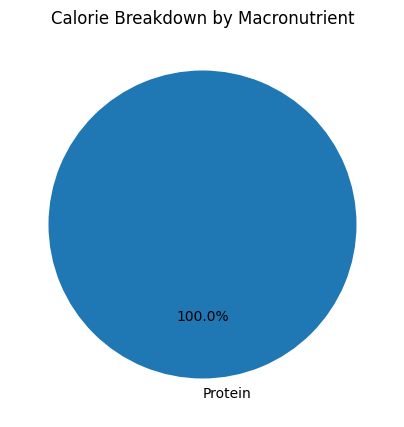

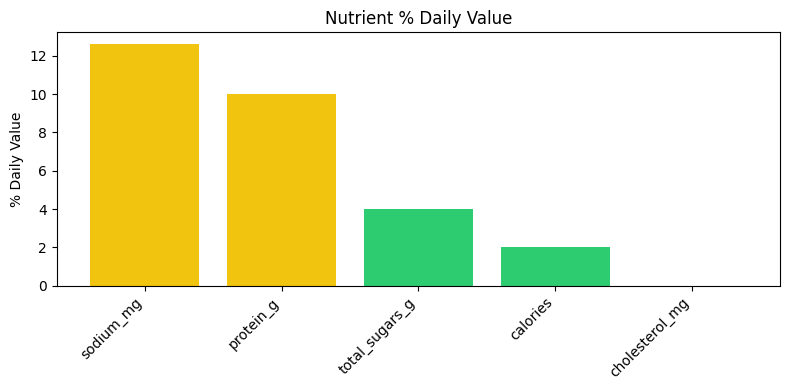



############################################################
# Create a modern and clean label for organic coconut oil 500ml jar _ Product label contest (2).jpg
############################################################
⚠️ Image quality warning: ['Image looks overexposed/glare (brightness: 225.9/255)']
FOOD LABEL ANALYSIS REPORT

📊 NUTRITION DATA:

📈 % DAILY VALUE:

💡 HEALTH INSIGHTS:

🍬 GLYCEMIC RISK: {'net_carbs_g': 0, 'blood_sugar_spike_risk': 'LOW'}

🏷️ NUTRI-SCORE: N/A — N/A
🌍 ECO-SCORE: N/A — N/A
🏭 PROCESSING LEVEL: {'nova_group': None, 'meaning': 'Unknown'}

⭐ HEALTH SCORE: N/A (no nutrition data extracted)
No macro data to plot
No %DV data to plot


############################################################
# 15270086238248702 (2).jpg
############################################################
FOOD LABEL ANALYSIS REPORT

📊 NUTRITION DATA:

📈 % DAILY VALUE:

💡 HEALTH INSIGHTS:

🍬 GLYCEMIC RISK: {'net_carbs_g': 0, 'blood_sugar_spike_risk': 'LOW'}

🏷️ NUTRI-SCORE: N/A — N/A

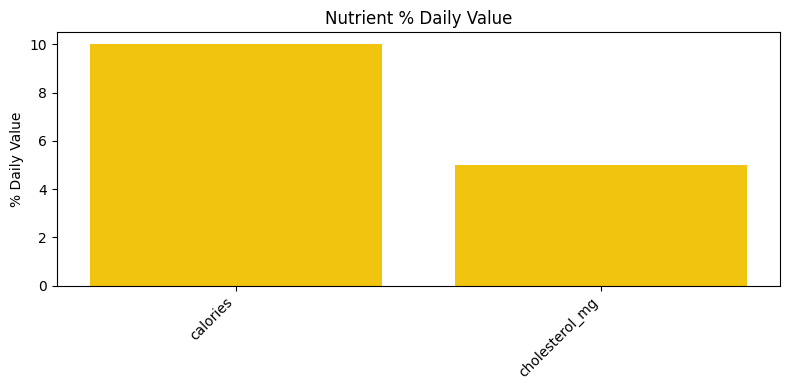



############################################################
# 53761789298017416 (2).jpg
############################################################
FOOD LABEL ANALYSIS REPORT

📊 NUTRITION DATA:
  calories: 160
  trans_fat_g: 0.0
  cholesterol_mg: 0.0
  sodium_mg: 150.0
  total_carbs_g: 15.0
  fiber_g: 1.4
  serving_size: 1 oz (28g/About 15 chips)

📈 % DAILY VALUE:
  calories: 8.0%
  cholesterol_mg: 0.0%
  sodium_mg: 6.5%
  total_carbs_g: 5.5%
  fiber_g: 5.0%

💡 HEALTH INSIGHTS:
  🟢 LOW: Cholesterol — only 0.0% of your daily value
  🟢 LOW: Fiber — only 5.0% of your daily value

🍬 GLYCEMIC RISK: {'net_carbs_g': 13.6, 'blood_sugar_spike_risk': 'LOW'}

🏷️ NUTRI-SCORE: N/A — N/A
🌍 ECO-SCORE: N/A — N/A
🏭 PROCESSING LEVEL: {'nova_group': None, 'meaning': 'Unknown'}

⭐ HEALTH SCORE: 90/100 (Excellent)

🥗 INGREDIENTS: ['== Potatoes', 'Vegetable Oil (Sunflower', 'Corn', 'and/or Canola Oil)', 'BLT Seasoning (Maltodextrin [Made From Corn}', 'Salt', 'Sour Cream [Cultured Cream', 'Skim Milk]', '

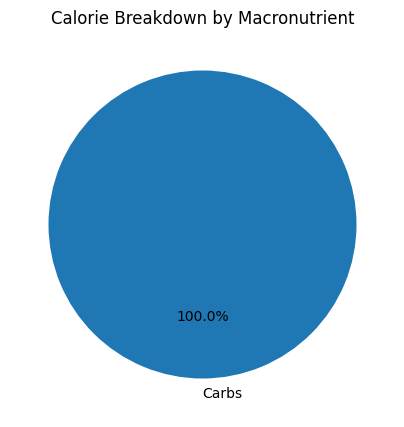

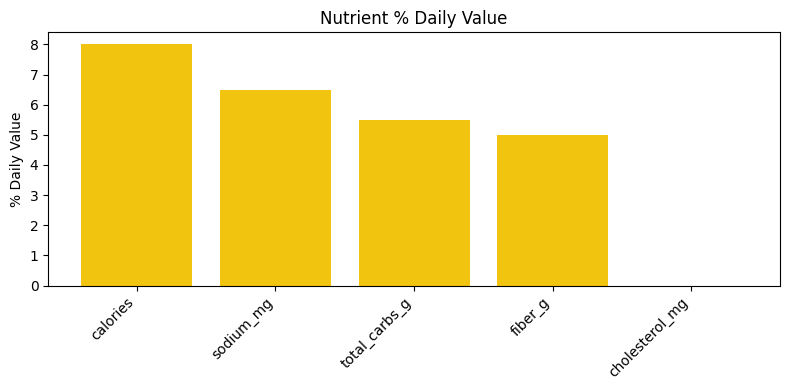



############################################################
# On Nutrition Data, you'll find detailed nutrition… (2).jpg
############################################################
FOOD LABEL ANALYSIS REPORT

📊 NUTRITION DATA:
  calories: 200
  total_fat_g: 1.0
  saturated_fat_g: 0.0
  cholesterol_mg: 0.0
  sodium_mg: 7.0
  fiber_g: 11.0
  total_sugars_g: 6.0
  protein_g: 13.0
  serving_size: 172g

📈 % DAILY VALUE:
  calories: 10.0%
  total_fat_g: 1.3%
  saturated_fat_g: 0.0%
  cholesterol_mg: 0.0%
  sodium_mg: 0.3%
  fiber_g: 39.3%
  total_sugars_g: 12.0%
  protein_g: 26.0%

💡 HEALTH INSIGHTS:
  🟢 LOW: Total Fat — only 1.3% of your daily value
  🟢 LOW: Saturated Fat — only 0.0% of your daily value
  🟢 LOW: Cholesterol — only 0.0% of your daily value
  🟢 LOW: Sodium — only 0.3% of your daily value
  🟡 MODERATE: Fiber — 39.3% of your daily value
  🟡 MODERATE: Protein — 26.0% of your daily value

🍬 GLYCEMIC RISK: {'net_carbs_g': -11.0, 'blood_sugar_spike_risk': 'LOW'}

🏷️ NUTRI-SCORE

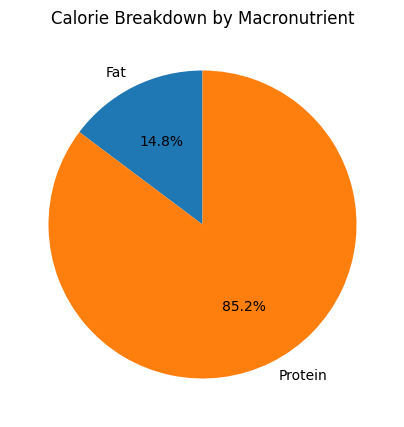

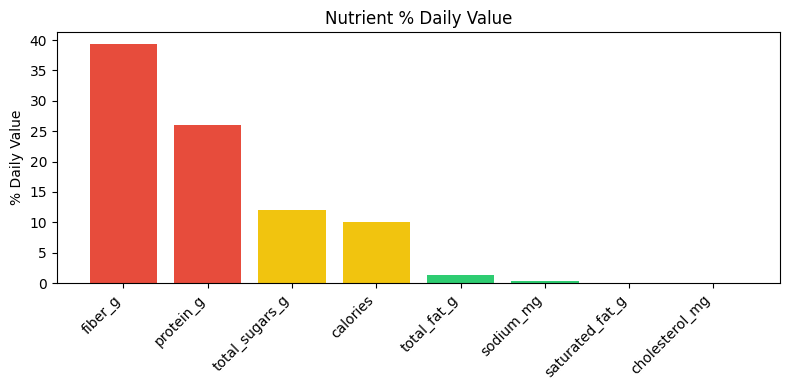



############################################################
# download (2).jpg
############################################################
FOOD LABEL ANALYSIS REPORT

📊 NUTRITION DATA:
  calories: 160
  total_fat_g: 8.0
  saturated_fat_g: 2.0
  trans_fat_g: 0.0
  cholesterol_mg: 0.0
  sodium_mg: 110.0
  total_carbs_g: 22.0
  fiber_g: 1.0
  total_sugars_g: 11.0
  serving_size: 3 cookies (33g)

📈 % DAILY VALUE:
  calories: 8.0%
  total_fat_g: 10.3%
  saturated_fat_g: 10.0%
  cholesterol_mg: 0.0%
  sodium_mg: 4.8%
  total_carbs_g: 8.0%
  fiber_g: 3.6%
  total_sugars_g: 22.0%

💡 HEALTH INSIGHTS:
  🟢 LOW: Cholesterol — only 0.0% of your daily value
  🟢 LOW: Sodium — only 4.8% of your daily value
  🟢 LOW: Fiber — only 3.6% of your daily value
  🟡 MODERATE: Total Sugars — 22.0% of your daily value

🍬 GLYCEMIC RISK: {'net_carbs_g': 21.0, 'blood_sugar_spike_risk': 'MODERATE'}

🏷️ NUTRI-SCORE: N/A — N/A
🌍 ECO-SCORE: N/A — N/A
🏭 PROCESSING LEVEL: {'nova_group': None, 'meaning': 'Unknown'}

⭐ 

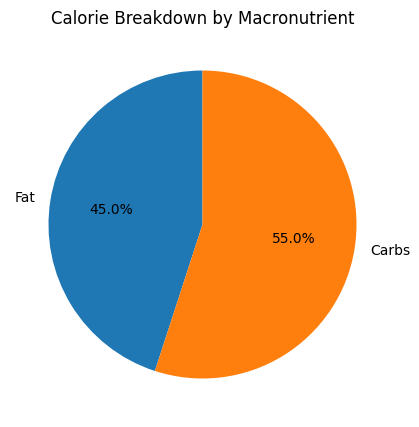

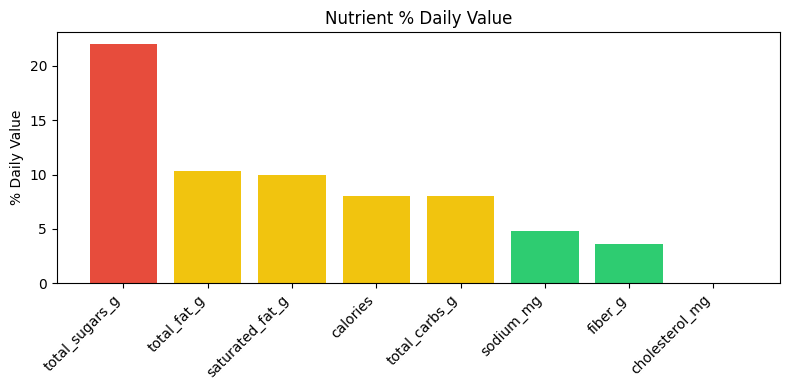

In [31]:
try:
    from google.colab import files
    print("📷 Please upload one or more nutrition label photos (Ctrl/Cmd+click to select multiple):")
    uploaded = files.upload()
    image_paths = list(uploaded.keys())
except ImportError:
    print("Not running on Colab — set image_paths manually below.")
    image_paths = ["label.jpg"]

my_profile = {
    'is_diabetic': False,
    'is_hypertensive': False,
    'is_kidney_patient': False,
    'allergies': [],          # e.g. ['soy', 'milk']
    'goal': 'maintenance',    # 'weight_loss', 'muscle_gain', or 'maintenance'
    'daily_calorie_budget': 2000,
}

# results is a dict keyed by filename, so you can look up any image's report later,
# e.g. results['label.jpg']['health_score']
results = {}
for path in image_paths:
    print(f"\n\n{'#' * 60}\n# {path}\n{'#' * 60}")
    results[path] = main(path, user_profile=my_profile)
    plot_macro_breakdown(results[path]['nutrition'])
    plot_dv_bar_chart(results[path]['daily_value_percent'])


## 13. Optional: export a report, or add more images later

`results` is a dict of every image you've processed so far (keyed by filename).
Run the cell above again anytime to upload and add more images — it appends
to `results` rather than overwriting it, since each run adds a new set of keys.

In [32]:
# Re-plot charts for one specific image by filename (charts already show
# automatically above, this is just if you want to see one again)
# plot_macro_breakdown(results['label.jpg']['nutrition'])
# plot_dv_bar_chart(results['label.jpg']['daily_value_percent'])


In [33]:
# Export a report (JSON + PDF) for every image processed so far
for fname, r in results.items():
    safe_name = fname.rsplit('.', 1)[0]
    export_report(r, filename=f"scan_report_{safe_name}.json")
    export_report_pdf(json.dumps(r, indent=2), filename=f"scan_report_{safe_name}.pdf")


Report saved as scan_report_IMG_20260808_152851.json
Report saved as scan_report_IMG_20260808_152835.json
Report saved as scan_report_IMG_20260808_152907.json
Report saved as scan_report_IMG_20260808_152808.json
Report saved as scan_report_Learn To Read The Nutrition Facts Table #FocusontheFacts (2).json
Report saved as scan_report_Create a modern and clean label for organic coconut oil 500ml jar _ Product label contest (2).json
Report saved as scan_report_15270086238248702 (2).json
Report saved as scan_report_14214555069679884 (2).json
Report saved as scan_report_53761789298017416 (2).json
Report saved as scan_report_On Nutrition Data, you'll find detailed nutrition… (2).json
Report saved as scan_report_download (2).json


In [34]:
# Batch mode: process every .jpg in the current folder
def batch_process_images(folder_glob="*.jpg"):
    results = []
    for img_path in glob.glob(folder_glob):
        try:
            r = main(img_path, save_to_db=False, verbose=False)
            results.append({'image': img_path, 'data': r['nutrition']})
        except Exception as e:
            results.append({'image': img_path, 'error': str(e)})
    return results

# batch_results = batch_process_images("*.jpg")
# print(batch_results)


In [35]:
# View everything saved to the local database so far
print(load_all_scans())


[{'product_name': 'Learn To Read The Nutrition Facts Table #FocusontheFacts.jpg', 'date': '2026-08-08', 'nutrition': {'calories': 40, 'cholesterol_mg': 0.0, 'sodium_mg': 290.0, 'total_sugars_g': 2.0, 'protein_g': 5.0}, 'health_score': 90}, {'product_name': '14214555069679884.jpg', 'date': '2026-08-08', 'nutrition': {'calories': 200, 'trans_fat_g': 0.0, 'cholesterol_mg': 15.0}, 'health_score': 90}, {'product_name': '53761789298017416.jpg', 'date': '2026-08-08', 'nutrition': {'calories': 160, 'trans_fat_g': 0.0, 'cholesterol_mg': 0.0, 'sodium_mg': 150.0, 'total_carbs_g': 15.0, 'fiber_g': 1.4, 'serving_size': '1 oz (28g/About 15 chips)'}, 'health_score': 90}, {'product_name': "On Nutrition Data, you'll find detailed nutrition….jpg", 'date': '2026-08-08', 'nutrition': {'calories': 200, 'total_fat_g': 1.0, 'saturated_fat_g': 0.0, 'cholesterol_mg': 0.0, 'sodium_mg': 7.0, 'fiber_g': 11.0, 'total_sugars_g': 6.0, 'protein_g': 13.0, 'serving_size': '172g'}, 'health_score': 90}, {'product_name': 